<a href="https://colab.research.google.com/github/SithphawitSangkaha/Deep-Learning-class/blob/main/projects/Copy_of_DL(3_2)_66110043_Sithphawit_Sangkaha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [60]:
!git config --global user.name "SithphawitSangkaha"
!git config --global user.email "66110043@kmitl.ac.th"

In [63]:
!git add .
!git commit -m "Deep-Learning-class"
!git push

fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git


In [51]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import scipy
from tensorflow.keras import backend as K
from matplotlib.ticker import MaxNLocator
from IPython.display import clear_output
from scipy import optimize
from matplotlib.gridspec import GridSpec
from IPython.display import Image
from tensorflow.keras import initializers
from IPython.display import Javascript
from datetime import datetime
import os
import random
import time

SEED = 42

# Set the environment variables for reproducibility.
os.environ['TF_DETERMINISTIC_OPS'] = '1' # Enable deterministic operations. (TensorFlow가 연산을 수행할 때 매번 동일한 순서와 방식을 사용하도록 결정론적(Deterministic) 연산을 활성화합니다.)
os.environ['TF_CUDNN_DETERMINISTIC'] = '1' # Force cuDNN to use deterministic algorithms. (GPU 연산 라이브러리인 cuDNN이 무작위성을 줄이고 결정론적 알고리즘만 사용하도록 강제합니다.)
os.environ['PYTHONHASHSEED'] = '0' # Fix Python hash seed for reproducibility. (파이썬의 문자열 및 객체 해시 생성 알고리즘에 고정된 시드(Seed)를 부여하여 무작위 요소를 제거합니다.)

# Set the environment variables for reproducibility.
tf.config.threading.set_inter_op_parallelism_threads(1) # 서로 독립적인 연산(Op)들을 동시에 병렬 처리할 때 사용할 쓰레드 수를 1개로 제한합니다.
tf.config.threading.set_intra_op_parallelism_threads(1) # 하나의 단일 연산(예: 대형 행렬 곱셈) 내부에서 멀티쓰레딩으로 나누어 처리할 쓰레드 수를 1개로 제한합니다.

# Set global random seeds
tf.random.set_seed(SEED) # 텐서플로 난수 생성기의 시드를 고정합니다.
np.random.seed(SEED) # 넘파이 난수 생성기의 시드를 고정합니다.
random.seed(SEED) # 파이썬 기본 random 모듈의 시드를 고정합니다.

initializer = tf.keras.initializers.GlorotNormal(seed=SEED) # 신경망 가중치 초기화 시 동일한 난수를 사용하도록 시드를 지정한 초기화 객체를 생성합니다.

In [52]:
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten, MaxPooling2D, Dropout, BatchNormalization
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [53]:
# # x in [-2*pi, 2*pi]
# x = np.linspace(-2 * np.pi, 2 * np.pi, 1000)
# # Analytical solution
def true_function(x):
  return (np.exp(-x**2) * np.sin(5*x) + np.tanh(x)*np.cos(10*x**2))
# y = f(x)
# 1. The Core Requirement: Self-Supervised PINN Loss Function
def pinn_loss(x_true, y_pred):
    y_actual = true_function(x_true)
    # Return the RMSE between the network's prediction and the equation's output
    return tf.sqrt(tf.reduce_mean(tf.square(y_pred - y_actual)))

In [54]:
# Split into 800 training samples and 200 test samples
# Generate the full 1000 points
x_all = np.linspace(-2 * np.pi, 2 * np.pi, 1000).reshape(-1, 1)
x_train, x_test = train_test_split(x_all, test_size=200, random_state=SEED)

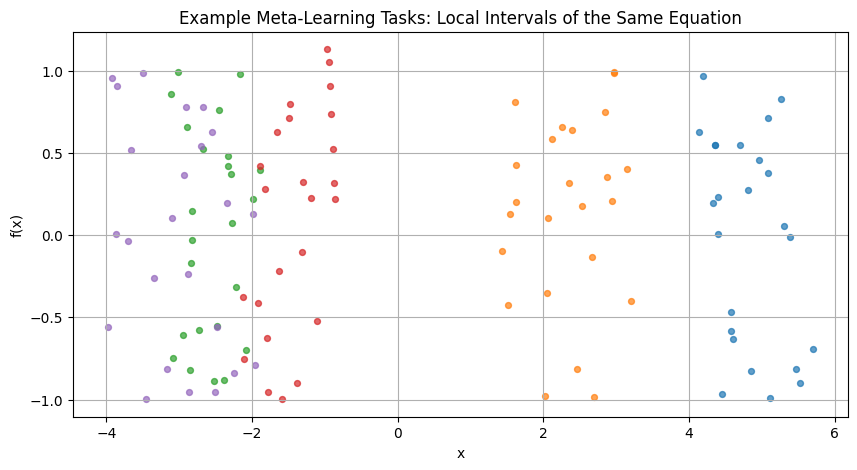

In [55]:
# Original assignment data: 800 training inputs and 200 final-test inputs
x_all = np.linspace(-2 * np.pi, 2 * np.pi, 1000).reshape(-1, 1)
x_train, x_test = train_test_split(x_all, test_size=200, random_state=SEED)

def analytical_function(x):
    return (
        np.exp(-x**2) * np.sin(5 * x)
        + np.tanh(x) * np.cos(10 * x**2)
    )

# Meta-learning settings
task_No = 4                 # tasks in each meta-epoch
support_size = 24           # few-shot support points per task
query_size = 48             # query points per task
min_interval_width = 1.2
max_interval_width = 2.4

def generate_meta_task(
    support_size=support_size,
    query_size=query_size
):
    """
    One task is the original equation restricted to a random local interval.
    Support and query points are distinct.
    """
    width = np.random.uniform(min_interval_width, max_interval_width)

    left = np.random.uniform(
        -2 * np.pi,
        2 * np.pi - width
    )
    right = left + width

    x_support = np.random.uniform(
        left, right, support_size
    ).reshape(-1, 1).astype(np.float32)

    x_query = np.random.uniform(
        left, right, query_size
    ).reshape(-1, 1).astype(np.float32)

    return x_support, x_query

# Visualize a few example tasks
plt.figure(figsize=(10, 5))

for _ in range(5):
    support_x, query_x = generate_meta_task()

    plt.scatter(
        support_x,
        analytical_function(support_x),
        s=18,
        alpha=0.7
    )

plt.title("Example Meta-Learning Tasks: Local Intervals of the Same Equation")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)
plt.show()

In [56]:
# 3. Model Architecture (Fourier Features + MLP)
class FourierFeatureMapping(tf.keras.layers.Layer):
    def __init__(self, num_features=256, scale=12.0, **kwargs):
        super().__init__(**kwargs)
        self.num_features = num_features
        self.scale = scale

    def build(self, input_shape):
        self.b = self.add_weight(
            shape=(input_shape[-1], self.num_features),
            initializer=tf.keras.initializers.RandomNormal(stddev=self.scale, seed=SEED),
            trainable=False,
            name='fourier_b'
        )
        super().build(input_shape)

    def call(self, inputs):
        proj = 2.0 * np.pi * tf.matmul(inputs, self.b)
        return tf.concat([tf.sin(proj), tf.cos(proj)], axis=-1)
#MLP
def create_model():
    model_instance = tf.keras.Sequential([
        tf.keras.layers.InputLayer(input_shape=(1,)),
        FourierFeatureMapping(num_features=128, scale=3.0),
        tf.keras.layers.Dense(256, activation='swish', kernel_initializer=initializer),
        tf.keras.layers.Dense(256, activation='swish', kernel_initializer=initializer),
        tf.keras.layers.Dense(256, activation='swish', kernel_initializer=initializer),
        tf.keras.layers.Dense(1, kernel_initializer=initializer)
    ])
    return model_instance

In [57]:
# FOMAML hyperparameters
meta_learning_rate = 0.001
inner_learning_rate = 0.01

meta_epochs = 250
inner_steps = 3

# Final fine-tuning settings, preserving the original assignment objective
final_learning_rate = 0.001
final_epochs = 2000
final_batch_size = 800

In [58]:
# First-Order Model-Agnostic Meta-Learning (FOMAML)
# This learns an initialization that adapts quickly to a local interval task.

meta_model = create_model()
meta_optimizer = tf.keras.optimizers.Adam(
    learning_rate=meta_learning_rate
)

def adapt_model(
    initial_model,
    support_x,
    steps=inner_steps
):
    """
    Create a temporary model and adapt it to one support set.
    The meta-model itself is never changed in the inner loop.
    """
    fast_model = create_model()
    fast_model.set_weights(initial_model.get_weights())

    inner_optimizer = tf.keras.optimizers.SGD(
        learning_rate=inner_learning_rate
    )

    for _ in range(steps):
        with tf.GradientTape() as tape:
            prediction = fast_model(support_x, training=True)
            support_loss = pinn_loss(support_x, prediction)

        gradients = tape.gradient(
            support_loss,
            fast_model.trainable_variables
        )

        inner_optimizer.apply_gradients(
            zip(gradients, fast_model.trainable_variables)
        )

    return fast_model

def fomaml_train_step(meta_model):
    """
    FOMAML:
    1. Create several local-interval tasks.
    2. Adapt a temporary model on each task's support points.
    3. Calculate query gradients after adaptation.
    4. Apply their average to the shared meta-model initialization.
    """
    accumulated_gradients = [
        tf.zeros_like(variable)
        for variable in meta_model.trainable_variables
    ]

    total_query_loss = 0.0

    for _ in range(task_No):
        support_x, query_x = generate_meta_task()

        support_x = tf.convert_to_tensor(
            support_x,
            dtype=tf.float32
        )
        query_x = tf.convert_to_tensor(
            query_x,
            dtype=tf.float32
        )

        # Inner loop: adapt a temporary copy
        fast_model = adapt_model(meta_model, support_x)

        # Outer-loop signal: evaluate adapted model on query data
        with tf.GradientTape() as tape:
            query_prediction = fast_model(query_x, training=True)
            query_loss = pinn_loss(query_x, query_prediction)

        query_gradients = tape.gradient(
            query_loss,
            fast_model.trainable_variables
        )

        accumulated_gradients = [
            total_gradient + gradient
            for total_gradient, gradient in zip(
                accumulated_gradients,
                query_gradients
            )
        ]

        total_query_loss += query_loss

    average_gradients = [
        gradient / task_No
        for gradient in accumulated_gradients
    ]

    meta_optimizer.apply_gradients(
        zip(average_gradients, meta_model.trainable_variables)
    )

    return total_query_loss / task_No


meta_train_loss = []

print("Starting FOMAML meta-training...")

for epoch in range(1, meta_epochs + 1):
    loss_value = fomaml_train_step(meta_model)
    meta_train_loss.append(float(loss_value))

    if epoch == 1 or epoch % 25 == 0:
        print(
            f"Meta-epoch {epoch:03d}/{meta_epochs} "
            f"- Query RMSE: {loss_value:.6f}"
        )

print("FOMAML meta-training complete.")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Starting FOMAML meta-training...
Meta-epoch 001/250 - Query RMSE: 0.732223
Meta-epoch 025/250 - Query RMSE: 0.335365
Meta-epoch 050/250 - Query RMSE: 0.253542
Meta-epoch 075/250 - Query RMSE: 0.484458
Meta-epoch 100/250 - Query RMSE: 0.254572
Meta-epoch 125/250 - Query RMSE: 0.369618
Meta-epoch 150/250 - Query RMSE: 0.337871
Meta-epoch 175/250 - Query RMSE: 0.210752
Meta-epoch 200/250 - Query RMSE: 0.295818
Meta-epoch 225/250 - Query RMSE: 0.527556
Meta-epoch 250/250 - Query RMSE: 0.181909
FOMAML meta-training complete.


In [59]:
# Few-shot meta-learning evaluation:
# Test whether the learned initialization improves after adaptation.

few_support_x, few_query_x = generate_meta_task(
    support_size=16,
    query_size=100
)

few_support_x = tf.convert_to_tensor(
    few_support_x,
    dtype=tf.float32
)

few_query_x = tf.convert_to_tensor(
    few_query_x,
    dtype=tf.float32
)

# RMSE before adaptation
prediction_before = meta_model(few_query_x, training=False)
rmse_before = float(
    pinn_loss(few_query_x, prediction_before)
)

# Adapt using only 16 support points
few_shot_model = adapt_model(
    meta_model,
    few_support_x,
    steps=10
)

# RMSE after adaptation
prediction_after = few_shot_model(few_query_x, training=False)
rmse_after = float(
    pinn_loss(few_query_x, prediction_after)
)

print(f"Few-shot RMSE before adaptation: {rmse_before:.6f}")
print(f"Few-shot RMSE after adaptation:  {rmse_after:.6f}")


# Final fine-tuning on the original 800-point assignment training split
final_model = create_model()
final_model.set_weights(meta_model.get_weights())

final_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=final_learning_rate
    ),
    loss=pinn_loss
)

lr_callback = ReduceLROnPlateau(
    monitor="loss",
    factor=0.5,
    patience=50,
    min_lr=1e-6,
    verbose=1
)

early_stop_callback = tf.keras.callbacks.EarlyStopping(
    monitor="loss",
    patience=300,
    restore_best_weights=True,
    verbose=1
)

final_history = final_model.fit(
    x=x_train,
    y=x_train,
    validation_data=(x_test, x_test),
    epochs=final_epochs,
    batch_size=final_batch_size,
    callbacks=[
        lr_callback,
        early_stop_callback
    ],
    verbose=0
)

# Same final evaluation objective as the original notebook
y_pred_test = final_model.predict(x_test, verbose=0)
y_actual_test = analytical_function(x_test)

test_rmse = np.sqrt(
    np.mean((y_pred_test - y_actual_test) ** 2)
)

print(f"FINAL TEST RMSE (200 samples): {test_rmse:.6f}")

Few-shot RMSE before adaptation: 0.063602
Few-shot RMSE after adaptation:  0.055527


NotImplementedError: Cannot convert a symbolic tf.Tensor (compile_loss/pinn_loss/Neg:0) to a numpy array. This error may indicate that you're trying to pass a Tensor to a NumPy call, which is not supported.

In [ ]:
# Assignment plot: final meta-initialized PiNN versus analytical equation

y_pred_all = final_model.predict(x_all, verbose=0)
y_actual_all = analytical_function(x_all)

plt.figure(figsize=(12, 6))

plt.plot(
    x_all,
    y_actual_all,
    label="Analytical Output (Exact Equation)",
    color="tab:blue",
    linewidth=3,
    alpha=0.5
)

plt.plot(
    x_all,
    y_pred_all,
    label="Meta-Initialized PiNN Output",
    color="tab:orange",
    linestyle="--",
    linewidth=1.5
)

plt.title(
    "Meta-Learning PiNN Output vs Analytical Function\n"
    f"Final Test RMSE: {test_rmse:.6f}"
)

plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Meta-training and final fine-tuning histories

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(meta_train_loss, label="Meta Query RMSE")
axes[0].set_yscale("log")
axes[0].set_xlabel("Meta Epoch")
axes[0].set_ylabel("RMSE")
axes[0].set_title("FOMAML Meta-Training History")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(
    final_history.history["loss"],
    label="Fine-Tuning Train RMSE"
)

axes[1].plot(
    final_history.history["val_loss"],
    label="Fine-Tuning Validation RMSE"
)

axes[1].set_yscale("log")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("RMSE")
axes[1].set_title("Final PiNN Fine-Tuning History")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()